# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Hành vi người dùng trong web thương mại điện tử
## RetailRocket E-Commerce — User Event Anomaly Detection

---

## Mục tiêu
Phát hiện hành vi bất thường của người dùng dựa trên:
1. **Luật nghiệp vụ (Business Rules)** — Các vi phạm logic quy trình mua hàng
2. **Phân tích thống kê** — Phát hiện outlier theo phân phối

## Các loại bất thường cần phát hiện

| Mã | Loại bất thường | Luật nghiệp vụ |
|----|-----------------|----------------|
| BR-01 | **Bot scraper** | Quá nhiều sự kiện trong thời gian ngắn |
| BR-02 | **Sequence vi phạm** | Mua hàng không qua xem/thêm giỏ |
| BR-03 | **Click fraud** | Tỉ lệ xem cực cao, không mua |
| BR-04 | **Rapid-fire events** | Sự kiện liên tiếp < 1 giây |
| BR-05 | **Night crawler** | Hoạt động bất thường lúc đêm khuya |
| BR-06 | **Item hoarding** | Thêm giỏ quá nhiều lần cùng sản phẩm |
| BR-07 | **Session bomb** | Quá nhiều item xem trong 1 phiên |
| BR-08 | **Ghost buyer** | Transaction không có lịch sử xem trước đó |

## 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# Style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'normal'  : '#4CAF50',
    'anomaly' : '#F44336',
    'warning' : '#FF9800',
    'primary' : '#6C63FF',
    'dark'    : '#2D2D2D',
    'blue'    : '#2196F3',
    'teal'    : '#009688',
}
PALETTE_ANO = [COLORS['normal'], COLORS['anomaly']]

print('✅ Thư viện đã sẵn sàng!')

✅ Thư viện đã sẵn sàng!


## 2. Tải & Chuẩn Bị Dữ Liệu

In [2]:
print('📂 Đang tải dữ liệu events...')
events = pd.read_csv('./data/events.csv')

# Datetime features
events['datetime']  = pd.to_datetime(events['timestamp'], unit='ms')
events['date']      = events['datetime'].dt.date
events['hour']      = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek
events['minute']    = events['datetime'].dt.minute

# Sắp xếp theo visitor + time
events = events.sort_values(['visitorid', 'timestamp']).reset_index(drop=True)

# Tính time_diff giữa các sự kiện liên tiếp CÙNG visitor
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec']  = (events['timestamp'] - events['prev_timestamp']) / 1000  # ms → giây

print(f'✅ Tổng sự kiện     : {len(events):,}')
print(f'✅ Unique visitors  : {events["visitorid"].nunique():,}')
print(f'✅ Khoảng thời gian : {events["datetime"].min().date()} → {events["datetime"].max().date()}')
print(f'\n📋 Phân phối sự kiện:')
print(events['event'].value_counts())

📂 Đang tải dữ liệu events...
✅ Tổng sự kiện     : 2,756,101
✅ Unique visitors  : 1,407,580
✅ Khoảng thời gian : 2015-05-03 → 2015-09-18

📋 Phân phối sự kiện:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


## 3. Xây Dựng Feature Profile Cho Từng Visitor

Tạo bảng đặc trưng hành vi cho từng `visitorid` — đây là đơn vị phân tích bất thường.

In [3]:
print('⚙️  Xây dựng visitor behavior profile...')
print('=' * 60)

df = events.copy()

# === NHÓM 1: Thống kê cơ bản ===
total_events   = df.groupby('visitorid').size().rename('total_events')
active_days    = df.groupby('visitorid')['date'].nunique().rename('active_days')
unique_items   = df.groupby('visitorid')['itemid'].nunique().rename('unique_items')

# Sự kiện theo loại
ev_pivot = df.groupby(['visitorid','event']).size().unstack(fill_value=0)
ev_pivot.columns = [f'n_{c}' for c in ev_pivot.columns]
for col in ['n_view','n_addtocart','n_transaction']:
    if col not in ev_pivot.columns: ev_pivot[col] = 0

# === NHÓM 2: Tốc độ sự kiện ===
time_diffs = df.dropna(subset=['time_diff_sec'])
speed_stats = time_diffs.groupby('visitorid')['time_diff_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
)

# Số sự kiện cực nhanh (< 1 giây)
rapid_count = time_diffs[time_diffs['time_diff_sec'] < 1].groupby('visitorid').size().rename('rapid_fire_count')

# === NHÓM 3: Phân phối theo giờ ===
night_events = df[df['hour'].between(0, 5)].groupby('visitorid').size().rename('night_events')   # 0h-5h
peak_events  = df[df['hour'].between(9, 21)].groupby('visitorid').size().rename('peak_events')   # 9h-21h

# === NHÓM 4: Tỉ lệ chuyển đổi ===
profile = pd.concat([
    total_events, active_days, unique_items,
    ev_pivot, speed_stats,
    rapid_count, night_events, peak_events,
], axis=1).fillna(0)

# Tỉ lệ
profile['view_rate']     = profile['n_view'] / (profile['total_events'] + 1)
profile['atc_rate']      = profile['n_addtocart'] / (profile['n_view'] + 1)
profile['buy_rate']      = profile['n_transaction'] / (profile['n_view'] + 1)
profile['night_ratio']   = profile['night_events'] / (profile['total_events'] + 1)
profile['rapid_ratio']   = profile['rapid_fire_count'] / (profile['total_events'] + 1)
profile['events_per_day']= profile['total_events'] / (profile['active_days'] + 1)
profile['items_per_event']= profile['unique_items'] / (profile['total_events'] + 1)

print(f'✅ Profile shape: {profile.shape}')
print(f'✅ Features: {list(profile.columns)}')

⚙️  Xây dựng visitor behavior profile...
✅ Profile shape: (1407580, 20)
✅ Features: ['total_events', 'active_days', 'unique_items', 'n_addtocart', 'n_transaction', 'n_view', 'min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec', 'rapid_fire_count', 'night_events', 'peak_events', 'view_rate', 'atc_rate', 'buy_rate', 'night_ratio', 'rapid_ratio', 'events_per_day', 'items_per_event']


## 4. Phát Hiện Bất Thường Theo Luật Nghiệp Vụ (Business Rules)

> **Nguyên tắc**: Mỗi luật được định nghĩa rõ ràng với **ngưỡng** và **giải thích nghiệp vụ**.

In [4]:
# ============================================================
# THRESHOLDS (có thể điều chỉnh dựa trên domain knowledge)
# ============================================================
THRESHOLDS = {
    'BR01_max_events_per_day'      : 100,   # > 100 events/ngày → nghi bot
    'BR04_rapid_fire_ratio'        : 0.30,  # > 30% sự kiện < 1 giây
    'BR03_min_atc_rate'            : 0.001, # ATC rate gần 0 nhưng view rất nhiều
    'BR03_min_views_for_click_fraud': 50,   # Cần ít nhất 50 views để xét
    'BR05_night_ratio'             : 0.80,  # > 80% hoạt động ban đêm (0h-5h)
    'BR05_min_events_for_night'    : 10,    # Cần ≥ 10 events để xét
    'BR06_max_same_item_atc'       : 5,     # Thêm giỏ cùng sản phẩm > 5 lần
    'BR07_max_items_per_session'   : 200,   # Xem > 200 sản phẩm khác nhau/ngày
}

print('📌 Thresholds luật nghiệp vụ:')
for k, v in THRESHOLDS.items():
    print(f'  {k}: {v}')

📌 Thresholds luật nghiệp vụ:
  BR01_max_events_per_day: 100
  BR04_rapid_fire_ratio: 0.3
  BR03_min_atc_rate: 0.001
  BR03_min_views_for_click_fraud: 50
  BR05_night_ratio: 0.8
  BR05_min_events_for_night: 10
  BR06_max_same_item_atc: 5
  BR07_max_items_per_session: 200


In [5]:
anomalies = profile.copy()

# ─────────────────────────────────────────────────
# BR-01: BOT SCRAPER — Quá nhiều sự kiện mỗi ngày
# ─────────────────────────────────────────────────
anomalies['flag_BR01_bot_scraper'] = (
    anomalies['events_per_day'] > THRESHOLDS['BR01_max_events_per_day']
).astype(int)

# ─────────────────────────────────────────────────
# BR-02: GHOST BUYER — Mua hàng không qua addtocart
# ─────────────────────────────────────────────────
# Tính từ raw events: visitor có transaction nhưng không có addtocart
has_buy  = ev_pivot[ev_pivot['n_transaction'] > 0].index
has_atc  = ev_pivot[ev_pivot['n_addtocart'] > 0].index
ghost_buyers = has_buy.difference(has_atc)
anomalies['flag_BR02_ghost_buyer'] = anomalies.index.isin(ghost_buyers).astype(int)

# ─────────────────────────────────────────────────
# BR-02b: Mua hàng không qua view
# ─────────────────────────────────────────────────
has_view = ev_pivot[ev_pivot['n_view'] > 0].index
no_view_buyers = has_buy.difference(has_view)
anomalies['flag_BR02b_no_view_buyer'] = anomalies.index.isin(no_view_buyers).astype(int)

# ─────────────────────────────────────────────────
# BR-03: CLICK FRAUD — View nhiều, không bao giờ mua/thêm giỏ
# ─────────────────────────────────────────────────
anomalies['flag_BR03_click_fraud'] = (
    (anomalies['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud']) &
    (anomalies['n_addtocart'] == 0) &
    (anomalies['n_transaction'] == 0)
).astype(int)

# ─────────────────────────────────────────────────
# BR-04: RAPID FIRE — Tỉ lệ sự kiện cực nhanh cao
# ─────────────────────────────────────────────────
anomalies['flag_BR04_rapid_fire'] = (
    (anomalies['rapid_ratio'] > THRESHOLDS['BR04_rapid_fire_ratio']) &
    (anomalies['total_events'] > 5)
).astype(int)

# ─────────────────────────────────────────────────
# BR-05: NIGHT CRAWLER — Hầu hết hoạt động ban đêm
# ─────────────────────────────────────────────────
anomalies['flag_BR05_night_crawler'] = (
    (anomalies['night_ratio'] > THRESHOLDS['BR05_night_ratio']) &
    (anomalies['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

# ─────────────────────────────────────────────────
# BR-06: ITEM HOARDING — Thêm giỏ cùng sản phẩm nhiều lần
# ─────────────────────────────────────────────────
atc_events = df[df['event'] == 'addtocart']
same_item_atc = atc_events.groupby(['visitorid', 'itemid']).size()
hoarders = same_item_atc[same_item_atc > THRESHOLDS['BR06_max_same_item_atc']].reset_index()['visitorid'].unique()
anomalies['flag_BR06_item_hoarding'] = anomalies.index.isin(hoarders).astype(int)

# ─────────────────────────────────────────────────
# BR-07: SESSION BOMB — Xem quá nhiều sản phẩm/ngày
# ─────────────────────────────────────────────────
items_per_day = df.groupby(['visitorid', 'date'])['itemid'].nunique().groupby('visitorid').max()
items_per_day.name = 'max_items_per_day'
anomalies = anomalies.join(items_per_day)
anomalies['max_items_per_day'] = anomalies['max_items_per_day'].fillna(0)
anomalies['flag_BR07_session_bomb'] = (
    anomalies['max_items_per_day'] > THRESHOLDS['BR07_max_items_per_session']
).astype(int)

# ─────────────────────────────────────────────────
# TỔNG HỢP: Đếm số luật vi phạm
# ─────────────────────────────────────────────────
flag_cols = [c for c in anomalies.columns if c.startswith('flag_')]
anomalies['total_flags']     = anomalies[flag_cols].sum(axis=1)
anomalies['is_anomaly_rule'] = (anomalies['total_flags'] >= 1).astype(int)

print('✅ Đã áp dụng tất cả luật nghiệp vụ!')
print(f'\n📊 Tổng số vi phạm theo từng luật:')
for col in flag_cols:
    cnt = anomalies[col].sum()
    pct = cnt / len(anomalies) * 100
    rule_id = col.replace('flag_', '')
    print(f'  {rule_id:25s}: {cnt:6,} visitor ({pct:.2f}%)')

total_ano = anomalies['is_anomaly_rule'].sum()
print(f'\n🚨 TỔNG SỐ VISITOR BẤT THƯỜNG: {total_ano:,} / {len(anomalies):,} ({total_ano/len(anomalies)*100:.2f}%)')

✅ Đã áp dụng tất cả luật nghiệp vụ!

📊 Tổng số vi phạm theo từng luật:
  BR01_bot_scraper         :     13 visitor (0.00%)
  BR02_ghost_buyer         :  1,143 visitor (0.08%)
  BR02b_no_view_buyer      :    428 visitor (0.03%)
  BR03_click_fraud         :    506 visitor (0.04%)
  BR04_rapid_fire          :    167 visitor (0.01%)
  BR05_night_crawler       :  3,613 visitor (0.26%)
  BR06_item_hoarding       :    107 visitor (0.01%)
  BR07_session_bomb        :      6 visitor (0.00%)

🚨 TỔNG SỐ VISITOR BẤT THƯỜNG: 5,771 / 1,407,580 (0.41%)


In [6]:
# Phân tích visitor vi phạm nhiều luật nhất
multi_flag = anomalies[anomalies['total_flags'] >= 2].sort_values('total_flags', ascending=False)
print(f'Visitor vi phạm ≥ 2 luật: {len(multi_flag):,}')

print('\n🔴 Top 10 visitor bất thường nhất:')
display_cols = ['total_events', 'events_per_day', 'rapid_ratio', 'night_ratio', 'total_flags'] + flag_cols
display(multi_flag[display_cols].head(10))

Visitor vi phạm ≥ 2 luật: 204

🔴 Top 10 visitor bất thường nhất:


,total_events,events_per_day,rapid_ratio,night_ratio,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR02b_no_view_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb
visitorid,,,,,,,,,,,,,
413981,10,5.000000,0.363636,0.909091,3,0,0,0,0,1,1,1,0
1009201,20,10.000000,0.333333,0.952381,3,0,0,0,0,1,1,1,0
843438,12,6.000000,0.307692,0.923077,3,0,0,0,0,1,1,1,0
328055,11,5.500000,0.333333,0.916667,3,0,0,1,0,1,1,0,0
1317636,23,11.500000,0.541667,0.958333,3,0,0,0,0,1,1,1,0
683474,11,5.500000,0.333333,0.833333,3,0,0,0,0,1,1,1,0
513176,10,5.000000,0.454545,0.909091,3,0,0,0,0,1,1,1,0
40651,10,5.000000,0.363636,0.909091,3,0,0,0,0,1,1,1,0
1032742,255,28.333333,0.101562,0.882812,2,0,0,0,0,0,1,1,0


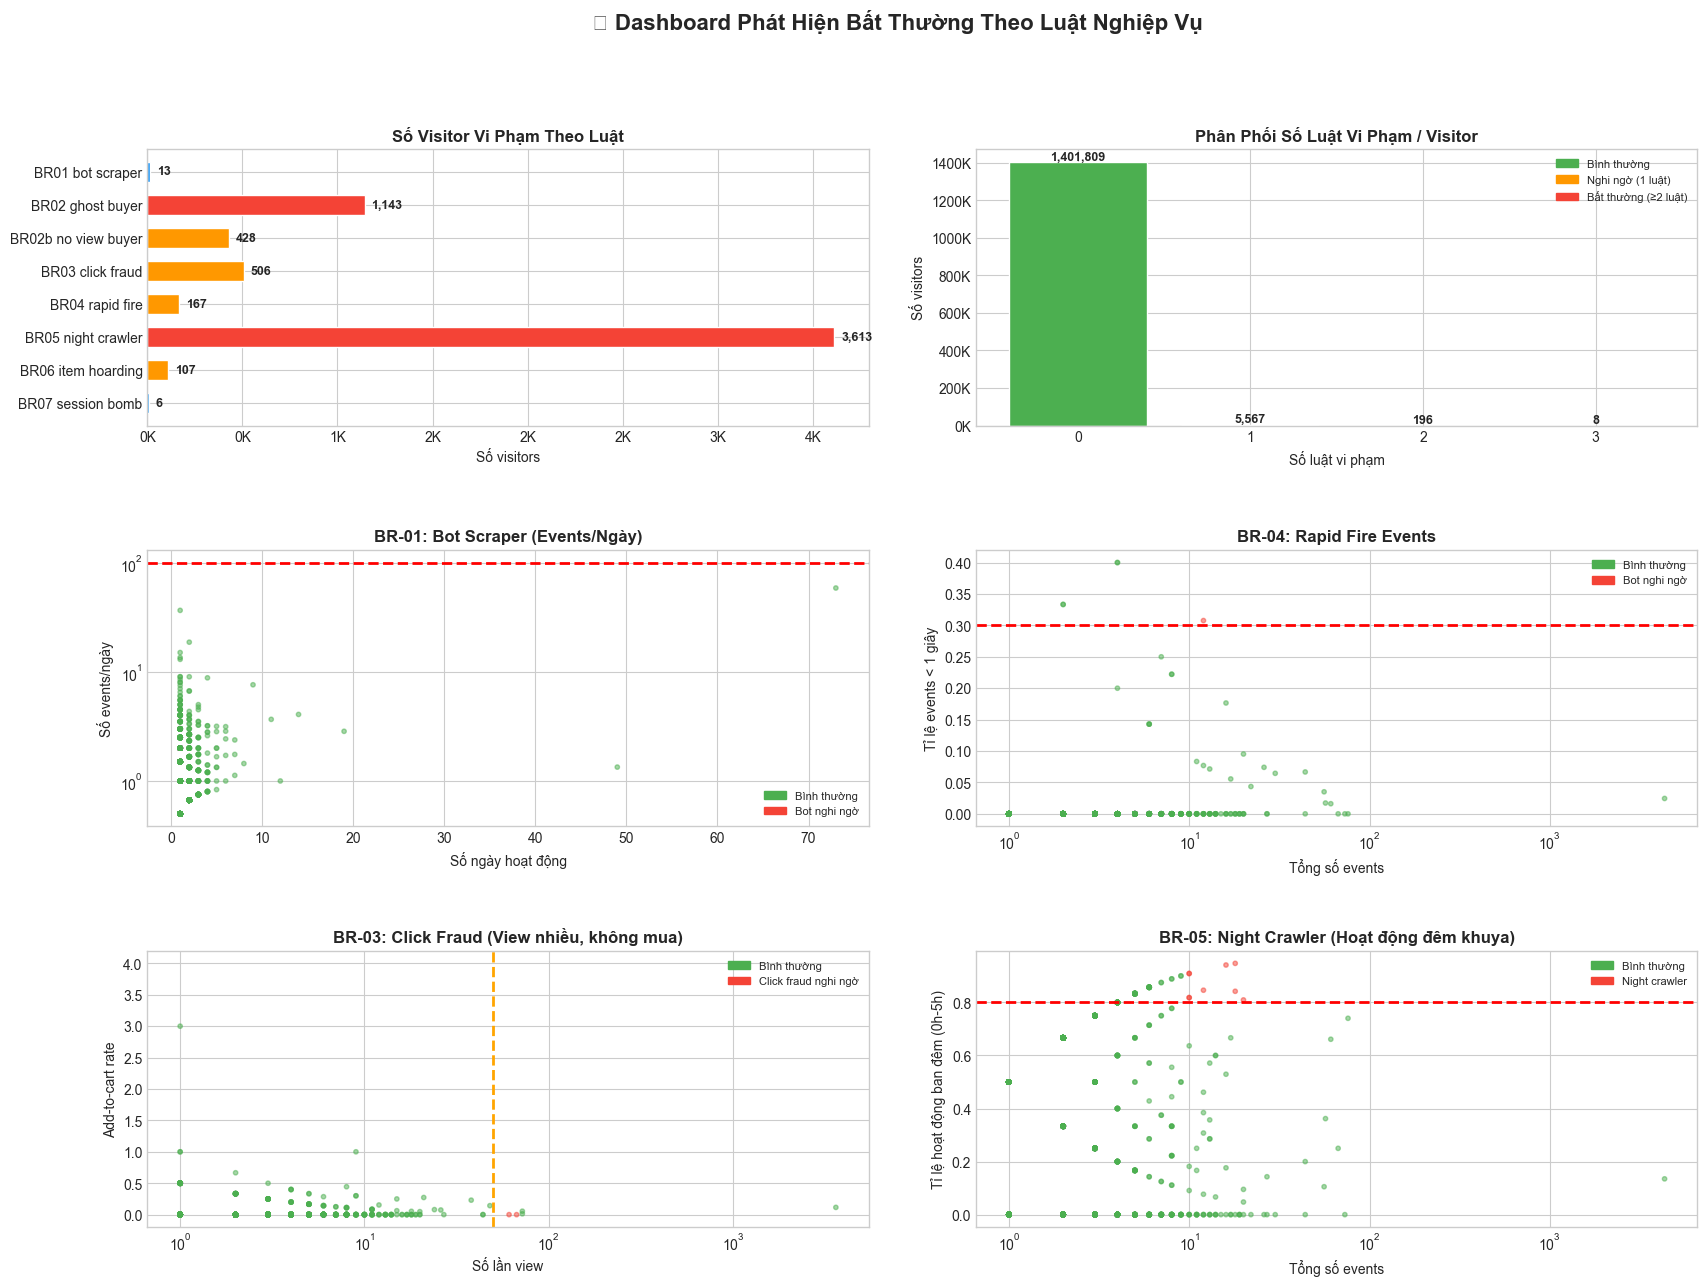

💾 Đã lưu: output_anomaly_business_rules.png


In [7]:
# ============================================================
# VISUALIZATION: Business Rules Dashboard
# ============================================================
fig = plt.figure(figsize=(20, 14))
fig.suptitle('🚨 Dashboard Phát Hiện Bất Thường Theo Luật Nghiệp Vụ', 
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# ── 1. Tổng quan: số vi phạm mỗi luật ──
ax1 = fig.add_subplot(gs[0, :2])
rule_labels = [c.replace('flag_', '').replace('_', ' ') for c in flag_cols]
rule_counts = [anomalies[c].sum() for c in flag_cols]
colors_bar  = [COLORS['anomaly'] if c > 1000 else COLORS['warning'] if c > 100 else COLORS['blue']
               for c in rule_counts]
bars = ax1.barh(rule_labels[::-1], rule_counts[::-1], color=colors_bar[::-1], 
                edgecolor='white', height=0.6)
for bar, val in zip(bars, rule_counts[::-1]):
    ax1.text(bar.get_width() + max(rule_counts)*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('Số Visitor Vi Phạm Theo Luật', fontweight='bold')
ax1.set_xlabel('Số visitors')
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# ── 2. Phân phối số luật vi phạm ──
ax2 = fig.add_subplot(gs[0, 2:])
flag_dist = anomalies['total_flags'].value_counts().sort_index()
colors_dist = [COLORS['normal']] + [COLORS['warning']] + [COLORS['anomaly']] * (len(flag_dist) - 2)
bars2 = ax2.bar(flag_dist.index.astype(str), flag_dist.values, 
                color=colors_dist[:len(flag_dist)], edgecolor='white')
for bar, val in zip(bars2, flag_dist.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(flag_dist.values)*0.01,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Phân Phối Số Luật Vi Phạm / Visitor', fontweight='bold')
ax2.set_xlabel('Số luật vi phạm')
ax2.set_ylabel('Số visitors')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
legend_patches = [
    mpatches.Patch(color=COLORS['normal'],  label='Bình thường'),
    mpatches.Patch(color=COLORS['warning'], label='Nghi ngờ (1 luật)'),
    mpatches.Patch(color=COLORS['anomaly'], label='Bất thường (≥2 luật)'),
]
ax2.legend(handles=legend_patches, fontsize=8)

# ── 3. BR-01: Events/day scatter ──
ax3 = fig.add_subplot(gs[1, :2])
sample = anomalies.sample(min(5000, len(anomalies)), random_state=42)
colors_s = [COLORS['anomaly'] if r else COLORS['normal'] for r in sample['flag_BR01_bot_scraper']]
ax3.scatter(sample['active_days'], sample['events_per_day'], 
            c=colors_s, alpha=0.5, s=10)
ax3.axhline(y=THRESHOLDS['BR01_max_events_per_day'], color='red', 
            linestyle='--', linewidth=2, label=f'Ngưỡng BR-01: {THRESHOLDS["BR01_max_events_per_day"]} events/ngày')
ax3.set_title('BR-01: Bot Scraper (Events/Ngày)', fontweight='bold')
ax3.set_xlabel('Số ngày hoạt động')
ax3.set_ylabel('Số events/ngày')
ax3.set_yscale('log')
ax3.legend(fontsize=8)
n_patch = mpatches.Patch(color=COLORS['normal'],  label='Bình thường')
a_patch = mpatches.Patch(color=COLORS['anomaly'], label='Bot nghi ngờ')
ax3.legend(handles=[n_patch, a_patch], fontsize=8)

# ── 4. BR-04: Rapid fire ──
ax4 = fig.add_subplot(gs[1, 2:])
colors_r = [COLORS['anomaly'] if r else COLORS['normal'] for r in sample['flag_BR04_rapid_fire']]
ax4.scatter(sample['total_events'], sample['rapid_ratio'],
            c=colors_r, alpha=0.5, s=10)
ax4.axhline(y=THRESHOLDS['BR04_rapid_fire_ratio'], color='red',
            linestyle='--', linewidth=2)
ax4.set_title('BR-04: Rapid Fire Events', fontweight='bold')
ax4.set_xlabel('Tổng số events')
ax4.set_ylabel('Tỉ lệ events < 1 giây')
ax4.set_xscale('log')
ax4.legend(handles=[n_patch, a_patch], fontsize=8)

# ── 5. BR-03: Click fraud ──
ax5 = fig.add_subplot(gs[2, :2])
colors_cf = [COLORS['anomaly'] if r else COLORS['normal'] for r in sample['flag_BR03_click_fraud']]
ax5.scatter(sample['n_view'], sample['atc_rate'],
            c=colors_cf, alpha=0.5, s=10)
ax5.axvline(x=THRESHOLDS['BR03_min_views_for_click_fraud'], color='orange',
            linestyle='--', linewidth=2, label='Ngưỡng min views')
ax5.set_title('BR-03: Click Fraud (View nhiều, không mua)', fontweight='bold')
ax5.set_xlabel('Số lần view')
ax5.set_ylabel('Add-to-cart rate')
ax5.set_xscale('log')
cf_patch = mpatches.Patch(color=COLORS['anomaly'], label='Click fraud nghi ngờ')
ax5.legend(handles=[n_patch, cf_patch], fontsize=8)

# ── 6. BR-05: Night crawler ──
ax6 = fig.add_subplot(gs[2, 2:])
colors_nc = [COLORS['anomaly'] if r else COLORS['normal'] for r in sample['flag_BR05_night_crawler']]
ax6.scatter(sample['total_events'], sample['night_ratio'],
            c=colors_nc, alpha=0.5, s=10)
ax6.axhline(y=THRESHOLDS['BR05_night_ratio'], color='red',
            linestyle='--', linewidth=2, label=f'Ngưỡng: {THRESHOLDS["BR05_night_ratio"]*100:.0f}% đêm')
ax6.set_title('BR-05: Night Crawler (Hoạt động đêm khuya)', fontweight='bold')
ax6.set_xlabel('Tổng số events')
ax6.set_ylabel('Tỉ lệ hoạt động ban đêm (0h-5h)')
ax6.set_xscale('log')
nc_patch = mpatches.Patch(color=COLORS['anomaly'], label='Night crawler')
ax6.legend(handles=[n_patch, nc_patch], fontsize=8)

plt.savefig('output_anomaly_business_rules.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_business_rules.png')

## 5. 🤖 ML Anomaly Detection — Isolation Forest & LOF

Kết hợp **Machine Learning không giám sát** để phát hiện bất thường mà luật nghiệp vụ có thể bỏ sót.

In [8]:
print('🤖 Chuẩn bị features cho ML Anomaly Detection...')
print('=' * 60)

# Chọn features cho ML (loại bỏ các cột flag và target)
ml_features = [
    'total_events', 'active_days', 'unique_items',
    'n_view', 'n_addtocart', 'n_transaction',
    'min_interval_sec', 'mean_interval_sec', 'std_interval_sec',
    'rapid_fire_count', 'night_events', 'peak_events',
    'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'rapid_ratio', 'events_per_day',
    'items_per_event', 'max_items_per_day',
]

X_ml = anomalies[ml_features].fillna(0).replace([np.inf, -np.inf], 0)

# Dùng RobustScaler vì dữ liệu có nhiều outlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_ml)

print(f'✅ Shape: {X_scaled.shape}')
print(f'✅ Features: {ml_features}')

🤖 Chuẩn bị features cho ML Anomaly Detection...
✅ Shape: (1407580, 20)
✅ Features: ['total_events', 'active_days', 'unique_items', 'n_view', 'n_addtocart', 'n_transaction', 'min_interval_sec', 'mean_interval_sec', 'std_interval_sec', 'rapid_fire_count', 'night_events', 'peak_events', 'view_rate', 'atc_rate', 'buy_rate', 'night_ratio', 'rapid_ratio', 'events_per_day', 'items_per_event', 'max_items_per_day']


In [9]:
# ── Isolation Forest ──
print('⏳ Huấn luyện Isolation Forest...')
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # Giả định ~5% dữ liệu là bất thường
    random_state=42,
    n_jobs=-1,
)
iso_pred   = iso_forest.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal
iso_scores = iso_forest.score_samples(X_scaled) # Score âm hơn = bất thường hơn

anomalies['iso_forest_pred']  = (iso_pred == -1).astype(int)   # 1 = bất thường
anomalies['iso_forest_score'] = iso_scores                       # Càng âm = càng bất thường

iso_anomaly_count = anomalies['iso_forest_pred'].sum()
print(f'✅ Isolation Forest phát hiện: {iso_anomaly_count:,} bất thường ({iso_anomaly_count/len(anomalies)*100:.1f}%)')

# ── Local Outlier Factor ──
# LOF chậm hơn với dữ liệu lớn → sample 50K để demo
print('\n⏳ Huấn luyện Local Outlier Factor (sample 50K visitor)...')
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_lof = X_scaled[sample_idx]

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1,
)
lof_pred   = lof.fit_predict(X_lof)      # -1 = anomaly
lof_scores = -lof.negative_outlier_factor_  # Cao hơn = bất thường hơn

# Gán kết quả LOF vào anomalies
anomalies['lof_pred']  = 0
anomalies['lof_score'] = 0.0
anomalies.iloc[sample_idx, anomalies.columns.get_loc('lof_pred')]  = (lof_pred == -1).astype(int)
anomalies.iloc[sample_idx, anomalies.columns.get_loc('lof_score')] = lof_scores

lof_anomaly_count = anomalies['lof_pred'].sum()
print(f'✅ LOF phát hiện: {lof_anomaly_count:,} bất thường trong 50K sample ({lof_anomaly_count/len(sample_idx)*100:.1f}%)')

# ── Ensemble: Kết hợp business rules + ML ──
anomalies['is_anomaly_ml']   = ((anomalies['iso_forest_pred'] == 1) | (anomalies['lof_pred'] == 1)).astype(int)
anomalies['is_anomaly_final']= ((anomalies['is_anomaly_rule'] == 1) | (anomalies['is_anomaly_ml'] == 1)).astype(int)

print(f'\n📊 TỔNG HỢP PHÁT HIỆN BẤT THƯỜNG:')
print(f'  Business Rules     : {anomalies["is_anomaly_rule"].sum():,}')
print(f'  Isolation Forest   : {anomalies["iso_forest_pred"].sum():,}')
print(f'  LOF (50K sample)   : {anomalies["lof_pred"].sum():,}')
print(f'  ─────────────────────────')
print(f'  ENSEMBLE (OR)      : {anomalies["is_anomaly_final"].sum():,} ({anomalies["is_anomaly_final"].mean()*100:.1f}%)')

⏳ Huấn luyện Isolation Forest...
✅ Isolation Forest phát hiện: 70,379 bất thường (5.0%)

⏳ Huấn luyện Local Outlier Factor (sample 50K visitor)...
✅ LOF phát hiện: 2,500 bất thường trong 50K sample (5.0%)

📊 TỔNG HỢP PHÁT HIỆN BẤT THƯỜNG:
  Business Rules     : 5,771
  Isolation Forest   : 70,379
  LOF (50K sample)   : 2,500
  ─────────────────────────
  ENSEMBLE (OR)      : 72,775 (5.2%)


📉 Giảm chiều PCA để visualize...
✅ PCA explained variance: 100.0%


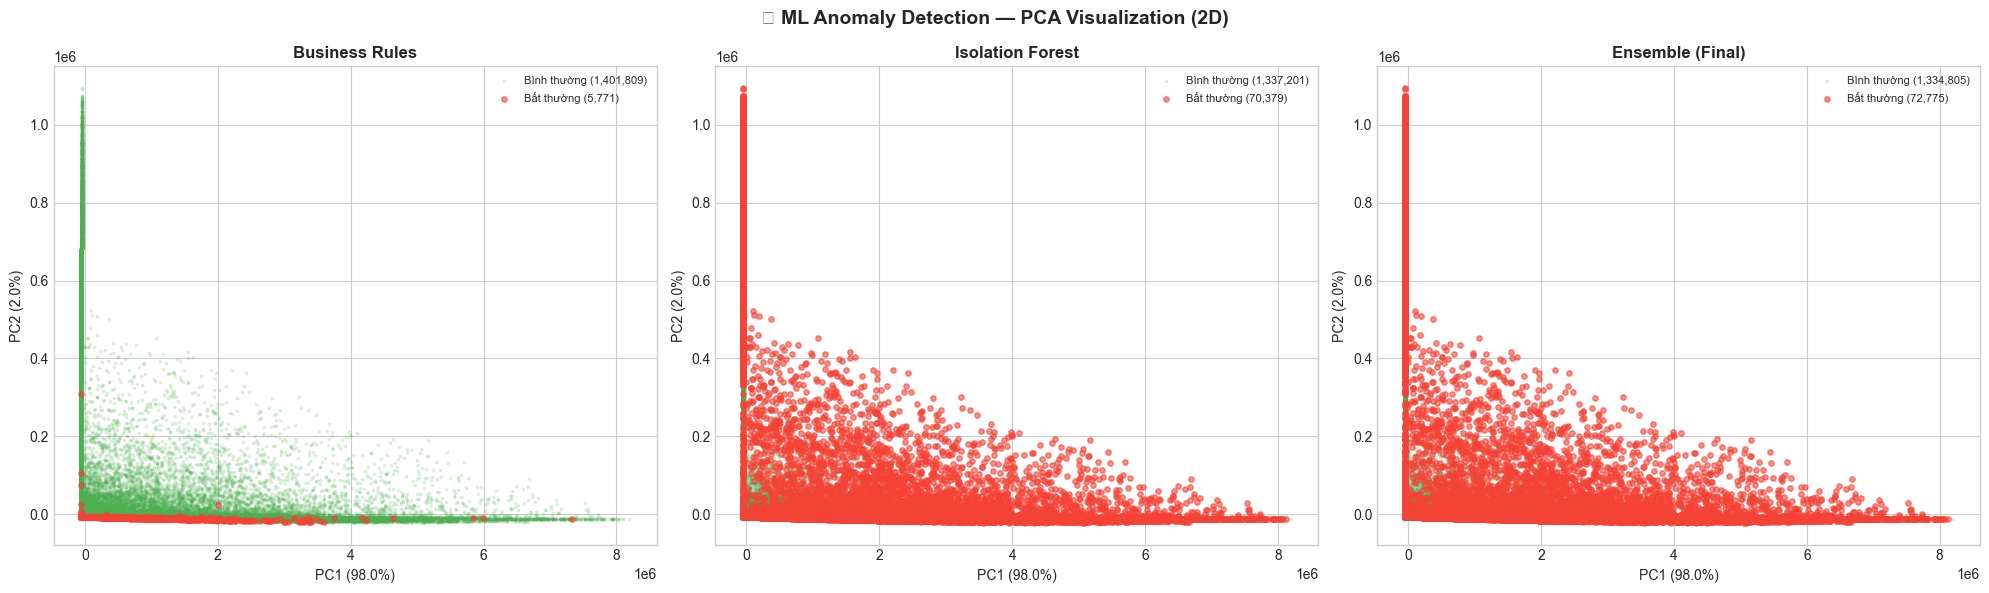

💾 Đã lưu: output_anomaly_pca.png


In [10]:
# PCA Visualization
print('📉 Giảm chiều PCA để visualize...')
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'✅ PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🤖 ML Anomaly Detection — PCA Visualization (2D)', 
             fontsize=14, fontweight='bold')

titles = ['Business Rules', 'Isolation Forest', 'Ensemble (Final)']
flags  = ['is_anomaly_rule', 'iso_forest_pred', 'is_anomaly_final']

for ax, title, flag in zip(axes, titles, flags):
    labels = anomalies[flag].values
    # Plot normal first
    mask_n = labels == 0
    ax.scatter(X_pca[mask_n, 0], X_pca[mask_n, 1], 
               c=COLORS['normal'], alpha=0.15, s=3, label=f'Bình thường ({mask_n.sum():,})')
    # Plot anomalies on top
    mask_a = labels == 1
    ax.scatter(X_pca[mask_a, 0], X_pca[mask_a, 1],
               c=COLORS['anomaly'], alpha=0.6, s=15, label=f'Bất thường ({mask_a.sum():,})', zorder=5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('output_anomaly_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_pca.png')

## 6. 📊 Phân Tích So Sánh: Bình Thường vs Bất Thường

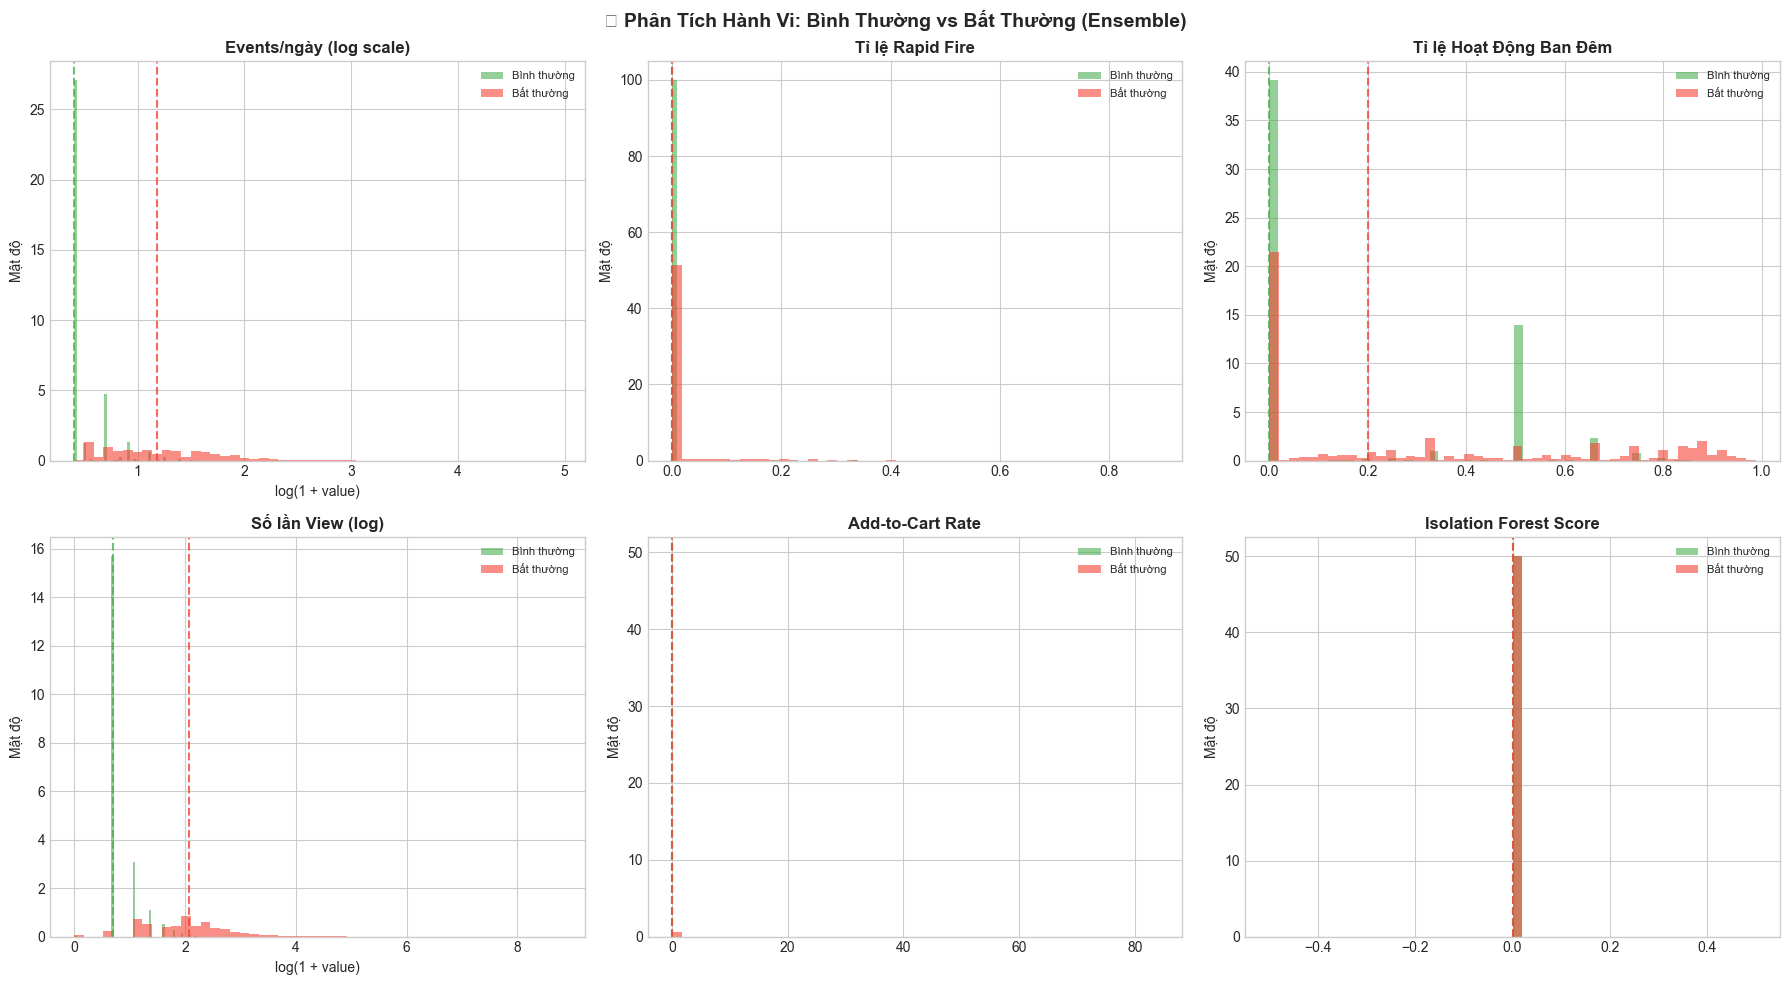

💾 Đã lưu: output_anomaly_comparison.png


In [11]:
# Isolation Forest anomaly score distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Phân Tích Hành Vi: Bình Thường vs Bất Thường (Ensemble)', 
             fontsize=14, fontweight='bold')

analyze_feats = [
    ('events_per_day',   'Events/ngày (log scale)',  True),
    ('rapid_ratio',      'Tỉ lệ Rapid Fire',         False),
    ('night_ratio',      'Tỉ lệ Hoạt Động Ban Đêm', False),
    ('n_view',           'Số lần View (log)',         True),
    ('atc_rate',         'Add-to-Cart Rate',          False),
    ('iso_forest_score', 'Isolation Forest Score',    False),
]

normal   = anomalies[anomalies['is_anomaly_final'] == 0]
abnormal = anomalies[anomalies['is_anomaly_final'] == 1]

for (feat, title, use_log), ax in zip(analyze_feats, axes.flatten()):
    d0 = normal[feat].clip(lower=0)
    d1 = abnormal[feat].clip(lower=0)
    
    if use_log:
        d0 = np.log1p(d0)
        d1 = np.log1p(d1)
    
    ax.hist(d0, bins=50, alpha=0.6, color=COLORS['normal'],  label='Bình thường', density=True)
    ax.hist(d1, bins=50, alpha=0.6, color=COLORS['anomaly'], label='Bất thường',  density=True)
    ax.axvline(d0.median(), color=COLORS['normal'],  linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(d1.median(), color=COLORS['anomaly'], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mật độ')
    if 'log' in title.lower(): ax.set_xlabel('log(1 + value)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output_anomaly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_comparison.png')

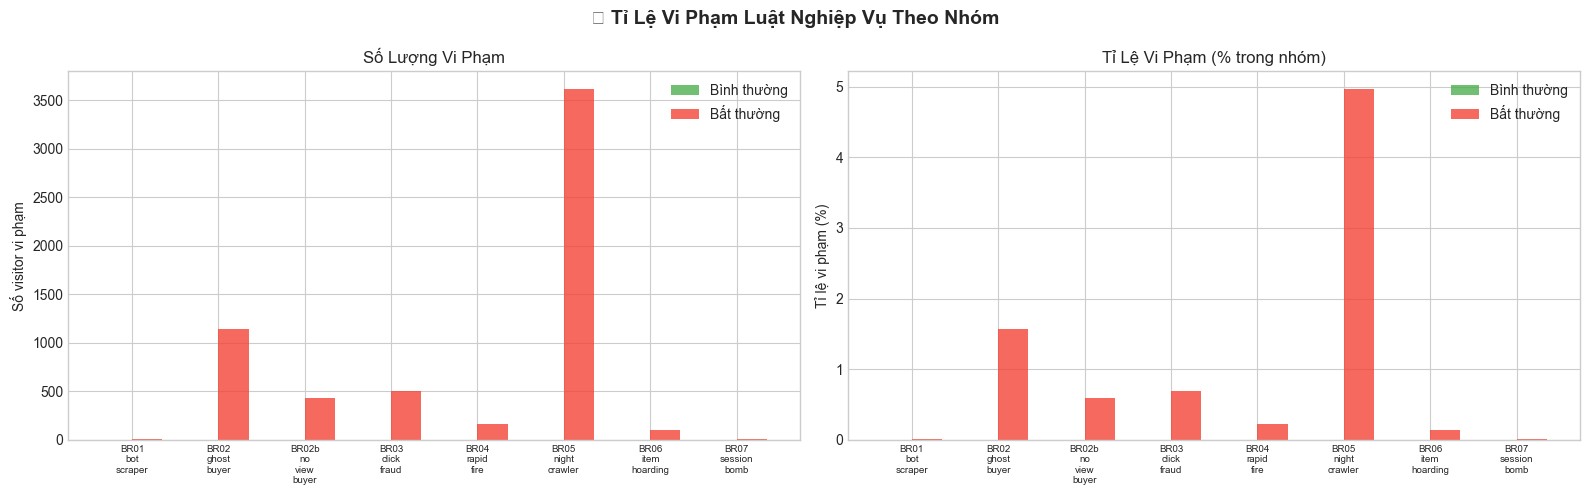

💾 Đã lưu: output_anomaly_rule_breakdown.png


In [12]:
# Heatmap: Tỉ lệ vi phạm luật trong từng nhóm
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🔥 Tỉ Lệ Vi Phạm Luật Nghiệp Vụ Theo Nhóm', fontsize=14, fontweight='bold')

# Stacked bar: số visitor mỗi nhóm
ax = axes[0]
rule_counts_normal   = [normal[c].sum() for c in flag_cols]
rule_counts_abnormal = [abnormal[c].sum() for c in flag_cols]
labels_short = [c.replace('flag_', '').replace('_', '\n') for c in flag_cols]
x = np.arange(len(flag_cols))
w = 0.35
ax.bar(x - w/2, rule_counts_normal,   w, label='Bình thường', color=COLORS['normal'],  alpha=0.8)
ax.bar(x + w/2, rule_counts_abnormal, w, label='Bất thường',  color=COLORS['anomaly'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=7)
ax.set_ylabel('Số visitor vi phạm')
ax.set_title('Số Lượng Vi Phạm')
ax.legend()

# Tỉ lệ vi phạm (% trong nhóm)
ax = axes[1]
rate_normal   = [normal[c].mean()*100 for c in flag_cols]
rate_abnormal = [abnormal[c].mean()*100 for c in flag_cols]
ax.bar(x - w/2, rate_normal,   w, label='Bình thường', color=COLORS['normal'],  alpha=0.8)
ax.bar(x + w/2, rate_abnormal, w, label='Bất thường',  color=COLORS['anomaly'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=7)
ax.set_ylabel('Tỉ lệ vi phạm (%)')
ax.set_title('Tỉ Lệ Vi Phạm (% trong nhóm)')
ax.legend()

plt.tight_layout()
plt.savefig('output_anomaly_rule_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_rule_breakdown.png')

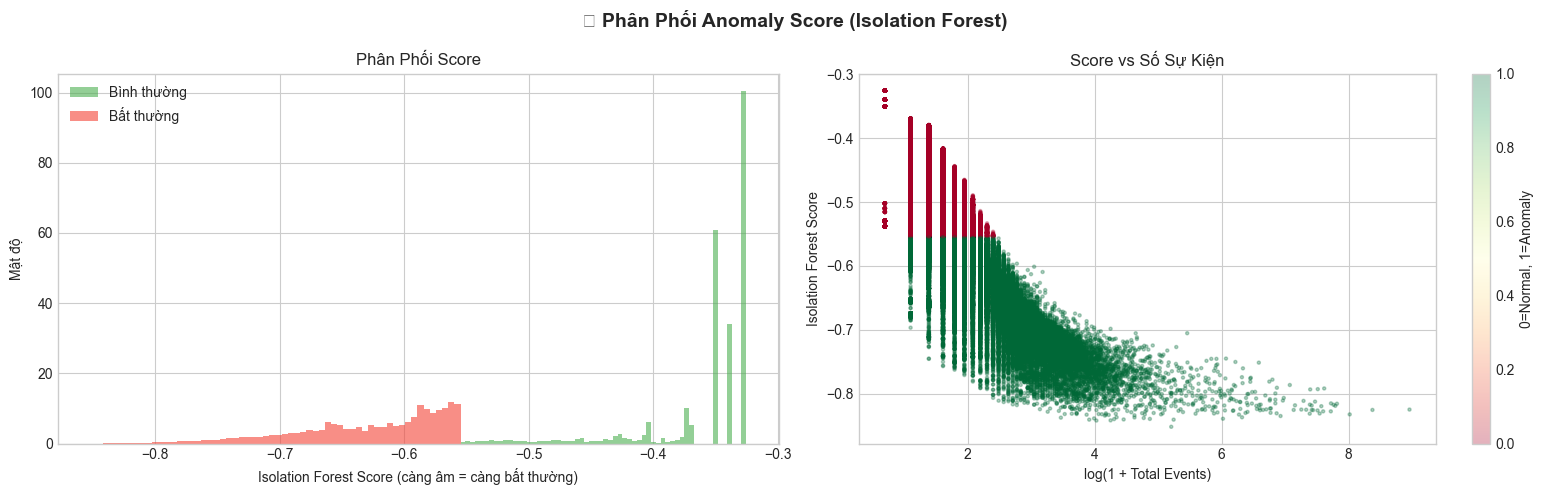

💾 Đã lưu: output_anomaly_scores.png


In [13]:
# Anomaly Score Visualization — Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📈 Phân Phối Anomaly Score (Isolation Forest)', fontsize=14, fontweight='bold')

# 1. Histogram score
ax = axes[0]
scores_n = anomalies[anomalies['iso_forest_pred'] == 0]['iso_forest_score']
scores_a = anomalies[anomalies['iso_forest_pred'] == 1]['iso_forest_score']
ax.hist(scores_n, bins=60, alpha=0.6, color=COLORS['normal'],  label='Bình thường', density=True)
ax.hist(scores_a, bins=60, alpha=0.6, color=COLORS['anomaly'], label='Bất thường',  density=True)
ax.set_xlabel('Isolation Forest Score (càng âm = càng bất thường)')
ax.set_ylabel('Mật độ')
ax.set_title('Phân Phối Score')
ax.legend()

# 2. Score theo total_events
ax = axes[1]
sc = ax.scatter(
    np.log1p(anomalies['total_events']),
    anomalies['iso_forest_score'],
    c=anomalies['iso_forest_pred'], 
    cmap='RdYlGn', alpha=0.3, s=5, vmin=0, vmax=1
)
ax.set_xlabel('log(1 + Total Events)')
ax.set_ylabel('Isolation Forest Score')
ax.set_title('Score vs Số Sự Kiện')
plt.colorbar(sc, ax=ax, label='0=Normal, 1=Anomaly')

plt.tight_layout()
plt.savefig('output_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_scores.png')

## 7. 🔍 Phân Tích Chi Tiết Case Study

Phân tích từng loại bất thường theo timeline sự kiện thực tế.

In [14]:
print('🔍 CASE STUDY - Phân tích timeline sự kiện của visitor bất thường')
print('=' * 70)

def show_visitor_timeline(visitor_id, label=''):
    """Hiển thị timeline sự kiện của một visitor."""
    v_events = events[events['visitorid'] == visitor_id].sort_values('timestamp')
    profile_row = anomalies.loc[visitor_id]
    
    print(f'\n👤 Visitor ID: {visitor_id} [{label}]')
    print(f'   Tổng sự kiện: {len(v_events)} | Active days: {v_events["date"].nunique()}')
    print(f'   Vi phạm luật: {[c.replace("flag_","") for c in flag_cols if profile_row[c] == 1]}')
    print(f'   ISO Score: {profile_row["iso_forest_score"]:.4f}')
    print('   Timeline (10 sự kiện đầu):')
    print(v_events[['datetime','event','itemid','time_diff_sec']].head(10).to_string(index=False))
    return v_events

# Bot scraper
bot_id = anomalies[anomalies['flag_BR01_bot_scraper'] == 1]['total_events'].idxmax()
show_visitor_timeline(bot_id, 'BR-01 Bot Scraper')

# Click fraud
fraud_candidates = anomalies[(anomalies['flag_BR03_click_fraud']==1) & (anomalies['n_view']>100)]
if len(fraud_candidates) > 0:
    fraud_id = fraud_candidates['n_view'].idxmax()
    show_visitor_timeline(fraud_id, 'BR-03 Click Fraud')

# Ghost buyer
ghost_candidates = anomalies[anomalies['flag_BR02_ghost_buyer'] == 1]
if len(ghost_candidates) > 0:
    ghost_id = ghost_candidates.index[0]
    show_visitor_timeline(ghost_id, 'BR-02 Ghost Buyer')

🔍 CASE STUDY - Phân tích timeline sự kiện của visitor bất thường

👤 Visitor ID: 1150086 [BR-01 Bot Scraper]
   Tổng sự kiện: 7757 | Active days: 74
   Vi phạm luật: ['BR01_bot_scraper', 'BR06_item_hoarding']
   ISO Score: -0.8252
   Timeline (10 sự kiện đầu):
               datetime       event  itemid  time_diff_sec
2015-06-11 14:55:17.389        view  133542            NaN
2015-06-11 15:15:35.608        view  167873       1218.219
2015-06-11 15:20:06.651        view  231726        271.043
2015-06-11 15:24:48.806        view  427777        282.155
2015-06-11 15:25:32.155        view  398115         43.349
2015-06-11 15:26:43.191   addtocart  398115         71.036
2015-06-11 15:28:45.614 transaction  398115        122.423
2015-06-11 15:29:03.539        view  398115         17.925
2015-06-11 15:32:07.711        view  203425        184.172
2015-06-11 15:34:51.672        view  458489        163.961

👤 Visitor ID: 310759 [BR-03 Click Fraud]
   Tổng sự kiện: 1177 | Active days: 48
   Vi phạ

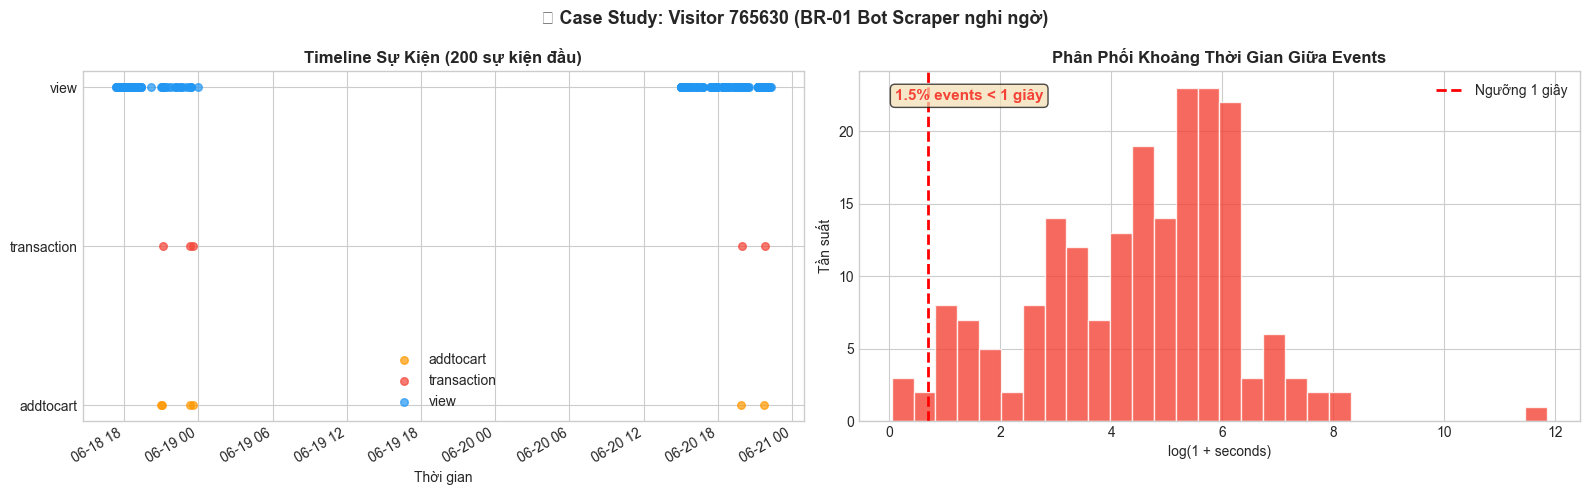

💾 Đã lưu: output_anomaly_case_study.png


In [15]:
# Visualize timeline của bot nghi ngờ nhất
bot_id = anomalies[anomalies['flag_BR01_bot_scraper'] == 1]['events_per_day'].idxmax()
v_events = events[events['visitorid'] == bot_id].sort_values('timestamp').head(200)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'🔬 Case Study: Visitor {bot_id} (BR-01 Bot Scraper nghi ngờ)', 
             fontsize=13, fontweight='bold')

# 1. Timeline sự kiện
ax = axes[0]
event_colors = {'view': COLORS['blue'], 'addtocart': COLORS['warning'], 'transaction': COLORS['anomaly']}
for event_type, grp in v_events.groupby('event'):
    ax.scatter(grp['datetime'], [event_type]*len(grp),
               c=event_colors.get(event_type, 'gray'), s=30, alpha=0.7, label=event_type)
ax.set_title('Timeline Sự Kiện (200 sự kiện đầu)', fontweight='bold')
ax.set_xlabel('Thời gian')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# 2. Phân phối interval giữa các event
ax = axes[1]
intervals = v_events['time_diff_sec'].dropna()
ax.hist(np.log1p(intervals.clip(lower=0)), bins=30, color=COLORS['anomaly'], alpha=0.8, edgecolor='white')
ax.axvline(np.log1p(1), color='red', linestyle='--', linewidth=2, label='Ngưỡng 1 giây')
ax.set_title('Phân Phối Khoảng Thời Gian Giữa Events', fontweight='bold')
ax.set_xlabel('log(1 + seconds)')
ax.set_ylabel('Tần suất')
ax.legend()
rapid_pct = (intervals < 1).mean() * 100
ax.text(0.05, 0.95, f'{rapid_pct:.1f}% events < 1 giây', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color=COLORS['anomaly'],
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('output_anomaly_case_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_case_study.png')

## 8. 📋 Anomaly Report & Export

In [ ]:
# Phân loại severity
def classify_severity(row):
    if row['total_flags'] >= 3 or (row['iso_forest_score'] < anomalies['iso_forest_score'].quantile(0.01)):
        return 'CRITICAL'
    elif row['total_flags'] == 2 or row['is_anomaly_ml'] == 1:
        return 'HIGH'
    elif row['total_flags'] == 1:
        return 'MEDIUM'
    else:
        return 'LOW'

anomalies['severity'] = anomalies.apply(classify_severity, axis=1)

severity_counts = anomalies[anomalies['is_anomaly_final']==1]['severity'].value_counts()
print('📊 Phân loại mức độ nghiêm trọng:')
print(severity_counts)

# Tạo anomaly report
report_cols = ['total_events', 'events_per_day', 'active_days',
               'rapid_ratio', 'night_ratio', 'atc_rate',
               'iso_forest_score', 'total_flags', 'severity'] + flag_cols

anomaly_report = anomalies[
    anomalies['is_anomaly_final'] == 1
][report_cols].sort_values(['severity', 'total_flags', 'iso_forest_score'],
                            ascending=[False, False, True])

# Export
anomaly_report.to_csv('anomaly_report.csv')
print(f'\n✅ Đã export: anomaly_report.csv ({len(anomaly_report):,} bản ghi)')
print('\n🔴 Top 10 bất thường nghiêm trọng nhất (CRITICAL):')
display(anomaly_report[anomaly_report['severity']=='CRITICAL'].head(10))

In [ ]:
# Final Summary Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('📋 Tổng Kết Phát Hiện Bất Thường', fontsize=14, fontweight='bold')

# 1. Pie - tỉ lệ bất thường
ax = axes[0]
pct_anomaly = anomalies['is_anomaly_final'].mean() * 100
wedge_sizes = [100 - pct_anomaly, pct_anomaly]
wedge_colors = [COLORS['normal'], COLORS['anomaly']]
wedges, texts, autotexts = ax.pie(
    wedge_sizes,
    labels=['Bình thường', 'Bất thường'],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.08),
    shadow=True,
)
for t in autotexts: t.set_fontweight('bold')
ax.set_title('Tỉ Lệ Tổng Thể', fontweight='bold')

# 2. Severity distribution
ax = axes[1]
sev_order = ['CRITICAL', 'HIGH', 'MEDIUM']
sev_colors = [COLORS['anomaly'], COLORS['warning'], '#FFC107']
sev_vals = [severity_counts.get(s, 0) for s in sev_order]
bars = ax.bar(sev_order, sev_vals, color=sev_colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, sev_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sev_vals)*0.01,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Phân Loại Mức Độ Nguy Hiểm', fontweight='bold')
ax.set_ylabel('Số visitors')

# 3. Venn-like: Overlap BR vs ML
ax = axes[2]
only_br = ((anomalies['is_anomaly_rule']==1) & (anomalies['is_anomaly_ml']==0)).sum()
only_ml = ((anomalies['is_anomaly_rule']==0) & (anomalies['is_anomaly_ml']==1)).sum()
both    = ((anomalies['is_anomaly_rule']==1) & (anomalies['is_anomaly_ml']==1)).sum()
cats = ['Chỉ\nBusiness Rules', 'Cả hai\n(Overlap)', 'Chỉ\nML']
vals = [only_br, both, only_ml]
bar_colors = [COLORS['blue'], COLORS['anomaly'], COLORS['teal']]
bars3 = ax.bar(cats, vals, color=bar_colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars3, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Phương Pháp Phát Hiện', fontweight='bold')
ax.set_ylabel('Số visitors')

plt.tight_layout()
plt.savefig('output_anomaly_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: output_anomaly_summary.png')

## 9. 🏁 Tổng Kết

In [ ]:
total_visitors = len(anomalies)
total_anomaly  = anomalies['is_anomaly_final'].sum()

print('=' * 70)
print('🎯 TỔNG KẾT HỆ THỐNG PHÁT HIỆN BẤT THƯỜNG')
print('=' * 70)
print(f'\n📊 Dataset: {len(events):,} sự kiện từ {total_visitors:,} visitors')
print(f'\n🔴 LUẬT NGHIỆP VỤ (Business Rules):')
rule_desc = {
    'BR01_bot_scraper'   : 'Bo quét dữ liệu (>100 events/ngày)',
    'BR02_ghost_buyer'   : 'Mua hàng không qua addtocart',
    'BR02b_no_view_buyer': 'Mua hàng không qua view',
    'BR03_click_fraud'   : 'Click fraud (view nhiều, không mua)',
    'BR04_rapid_fire'    : 'Sự kiện cực nhanh (<1 giây, >30%)',
    'BR05_night_crawler' : 'Hoạt động đêm khuya (>80% từ 0h-5h)',
    'BR06_item_hoarding' : 'Thêm giỏ cùng sản phẩm >5 lần',
    'BR07_session_bomb'  : 'Xem >200 sản phẩm khác nhau/ngày',
}
for col in flag_cols:
    cnt = anomalies[col].sum()
    key = col.replace('flag_', '')
    desc = rule_desc.get(key, key)
    print(f'  • {desc}: {cnt:,} visitor')
print(f'  → Tổng vi phạm luật: {anomalies["is_anomaly_rule"].sum():,} visitor')

print(f'\n🤖 ML ANOMALY DETECTION:')
print(f'  • Isolation Forest (5% contamination): {anomalies["iso_forest_pred"].sum():,} bất thường')
print(f'  • LOF (5% contamination, 50K sample)  : {anomalies["lof_pred"].sum():,} bất thường')

print(f'\n⚡ ENSEMBLE RESULT (Business Rules OR ML):')
print(f'  CRITICAL : {severity_counts.get("CRITICAL", 0):,} visitor')
print(f'  HIGH     : {severity_counts.get("HIGH", 0):,} visitor')
print(f'  MEDIUM   : {severity_counts.get("MEDIUM", 0):,} visitor')
print(f'  ─────────────────────────────────')
print(f'  TỔNG     : {total_anomaly:,} / {total_visitors:,} visitor ({total_anomaly/total_visitors*100:.1f}%)')

print(f'\n📁 Files đã export:')
for f in [
    'output_anomaly_business_rules.png',
    'output_anomaly_pca.png',
    'output_anomaly_comparison.png',
    'output_anomaly_rule_breakdown.png',
    'output_anomaly_scores.png',
    'output_anomaly_case_study.png',
    'output_anomaly_summary.png',
    'anomaly_report.csv',
]:
    print(f'  ✅ {f}')